# Rescue drone mission II: backward smoothing for refining trajectory estimates near a rocky shoreline.

## Roman Branovets, Skoltech, 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

### Trajectory generation and forward Kalman filter algorithm

Generating a true trajectory of the coordinate $𝒙_𝒊$ of an object's motion, perturbed by
normally distributed random acceleration $𝑎_𝑖$ with variance $\sigma^2_𝑎 = 0.2^2  (m/s^2)^2$. The trajectory
will consist of 200 points, starting with initial conditions $𝑥_0 = 5 𝑚$. , $𝑉_0 = 1$ 𝑚/𝑠. and a time
step $𝑇 = 1$ 𝑠.

$$
\begin{aligned}
x_i &= x_{i-1} + V_{i-1}T + \frac{a_i T^2}{2}\\
V_i &= V_{i-1} + a_i T
\end{aligned}
$$

In [2]:
#generating_trajectory
steps=200
x_real=np.zeros(steps)
v_real=np.zeros(steps)
t=1
x_real[0]=5
v_real[0]=1
for i in range(1,steps):
    a = np.random.normal(0,0.2)
    x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
    v_real[i]=v_real[i-1]+a*t
#generating_measurements
z=np.zeros(steps)
for i in range(0,steps):
    z[i]=x_real[i]+np.random.normal(0,20)

Let's define the parameters of this system

$$
\begin{aligned}
X_i &= \Phi X_{i-1} + Ga_i \\
z_i &= H_i X_i + \eta_i
\end{aligned}
$$

Where

- $X_{i}$ is the state vector
- $\Phi$ is the transition matrix that relates $X_{i}$ and $X_{i-1}$
- $G$ is the input matrix that defines how the random acceleration $a_{i}$ influences the state vector
- $z_{i}$ is the measurement vector, which in this case consists of a measurement of the coordinate $x_{i}$
- $H$ is the observation matrix that relates the measurement vector to the state vector
- $\eta_{i}$ is the measurement noise with the covariance matrix $R_{i}$

In [3]:
#transition matrix
fi=np.matrix([[1,t],[0,1]])
#input matrix
g=np.matrix([[(t**2)/2],[t]])
#observation matrix
h=np.matrix([1,0])
#state vector
X = np.zeros((len(x_real), 2, 1))
for i in range(len(x_real)):
    X[i] = np.array([[x_real[i]], [v_real[i]]])

Developing the forward Kalman filter algorithm

In [4]:
#Initial filtered estimate
X[0]=np.matrix([[2],[0]])
#Filtration error covariance matrix
P=np.zeros((steps, 2, 2))
P[0]=np.matrix([[10000, 0], [0, 10000]])
P_pred=np.zeros((steps, 2, 2))
P_pred[0]=np.matrix([[10000, 0], [0, 10000]])
#Covariance matrix
Q=(g@g.T)*(0.2**2)
R = np.array(20**2)
K = np.zeros((steps, 2, 1))
for i in range(1,len(x_real)):
    #step of prediction
    X[i]=fi@X[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    P_pred[i] = (fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)/E
    X[i]=X[i]+K[i]*(z[i]-h@X[i])
    P[i]=(np.identity(2)-K[i]@h)@P[i]

Developing a backward smoothing algorithm to refine the estimates of the state vector $𝑋_i$

Smoothing is performed backward in time

$$X_{i,N} = X_{i,i} + A_i(X_{i+1,N} - \Phi_{i+1,i}X_{i,i})$$

$$\begin{array}{c}
i
= N - 1, \, N - 2, \cdots 1
\end{array}$$

**Coefficient**  
$$A_i = P_{i,i}\Phi_{i+1,i}^TP_{i+1,i}^{-1}$$

**Smoothing error covariance matrix**

$$P_{i,N} = P_{i,i} + A_i(P_{i+1,N} - P_{i+1,i})A_i^T$$

$X_{i,i}$ - filtered estimate, $X_{N,N}$ - initial estimate  

$P_{i,i}$ - filtration error covariance matrix  

$P_{i+1,i}$ - prediction error covariance matrix

In [5]:
X_smoothed = np.zeros((steps,2,1))
X_smoothed[steps - 1] = X[steps -1]
P_smoothed = np.zeros((steps,2,2))
P_smoothed[steps - 1] = P[steps -1]
A = np.zeros((steps-1, 2, 2))
for i in range(steps - 2, -1, -1):
    A[i] = P[i]@fi.T@np.linalg.inv(P_pred[i+1])
    X_smoothed[i] = X[i] + A[i]@(X_smoothed[i+1]-fi@X[i])
    P_smoothed[i] = P[i] + A[i]@(P_smoothed[i+1]-P_pred[i+1])@A[i].T

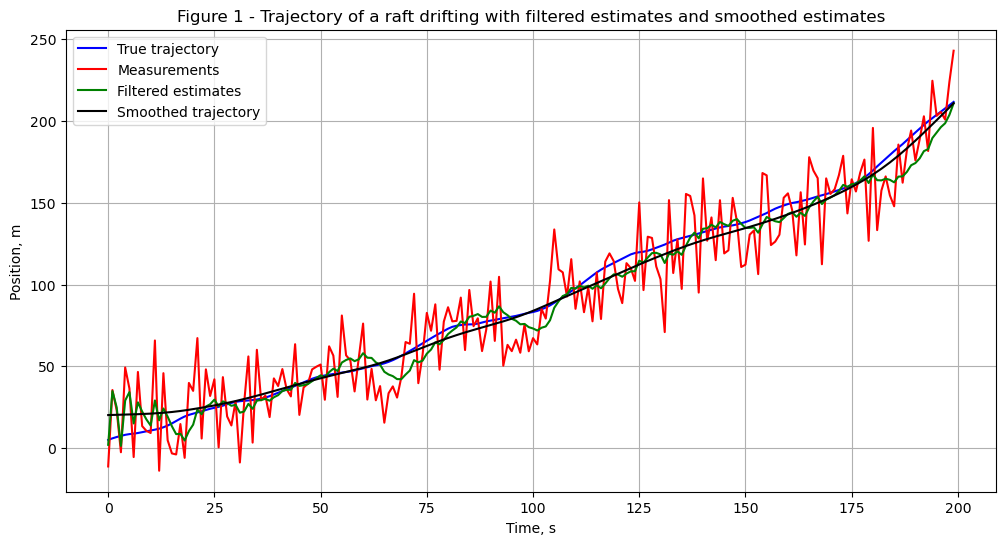

In [6]:
#Plots of real coordinates, measurements, filtered estimates and smoothed trajectory
plt.figure(figsize=(12, 6))
plt.plot(x_real, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(X[:,0,0], color='green',  label='Filtered estimates')
plt.plot(X_smoothed[:,0,0], color='black',  label='Smoothed trajectory')
plt.title('Figure 1 - Trajectory of a raft drifting with filtered estimates and smoothed estimates')
plt.xlabel('Time, s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

Let's perform an error estimation for both the filtering algorithm and the additional smoothing algorithm to see how the smoothing algorithm affects

Let's filter the data and plot the error graph at each step for coordinate x and velocity v.

In [7]:
#calculate error for filtration x
M=500
error=np.zeros((M,steps))
error1=np.zeros((M,steps))
fin_errfx=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[10000, 0], [0, 10000]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
        if i>1:
            error[o,i]=(x_real[i]-X[i,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_errfx[i]=fin_errfx[i]+((1/(M-1))*error[j,i])
    fin_errfx[i]=sqrt(fin_errfx[i])

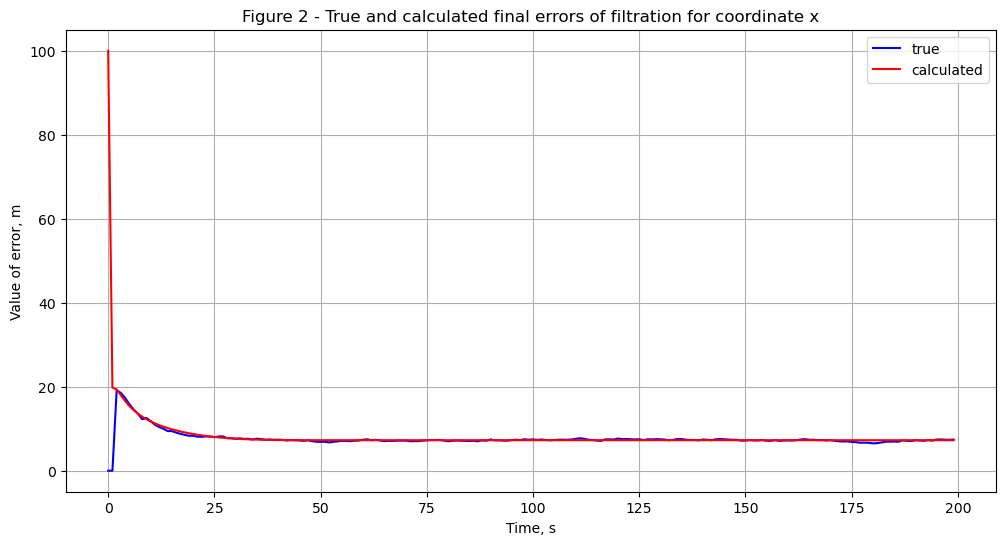

In [8]:
#Plot of the final error and matrix P
plt.figure(figsize=(12, 6))
plt.plot(fin_errfx, color="blue",  label='true')
plt.plot(np.sqrt(P[:,0,0]), color="red",  label='calculated')
plt.title('Figure 2 - True and calculated final errors of filtration for coordinate x')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

In [9]:
#calculate error for filtration v
M=500
error=np.zeros((M, steps))
error1=np.zeros((M, steps))
fin_errfv=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[10000, 0], [0, 10000]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
        if i>1:
            error[o,i]=(v_real[i]-X[i,1,0])**2
for i in range(steps):
    for j in range(M):
        fin_errfv[i]=fin_errfv[i]+((1/(M-1))*error[j,i])
    fin_errfv[i]=sqrt(fin_errfv[i])

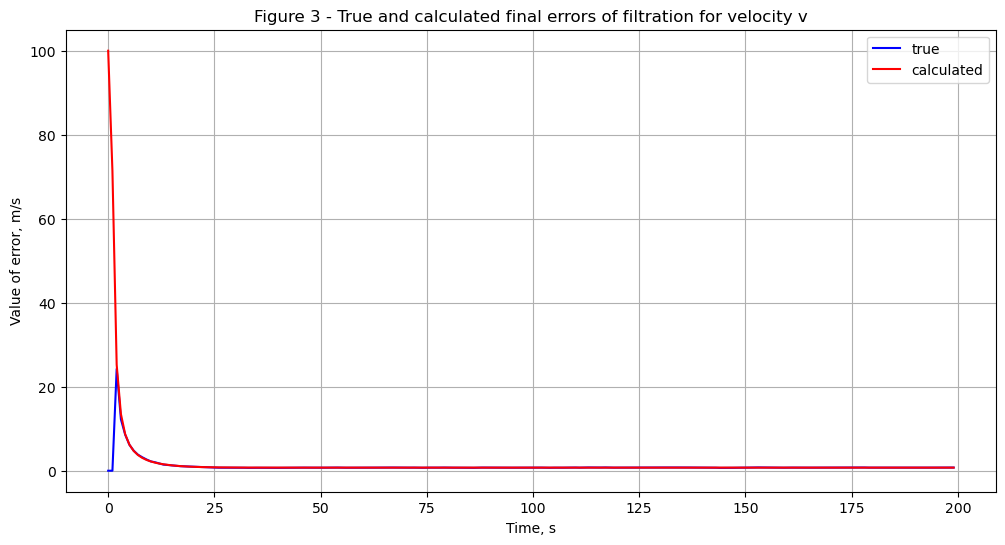

In [10]:
#Plot of the final error and matrix P
plt.figure(figsize=(12, 6))
plt.plot(fin_errfv, color="blue",  label='true')
plt.plot(np.sqrt(P[:,1,1]), color="red",  label='calculated')
plt.title('Figure 3 - True and calculated final errors of filtration for velocity v')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m/s')
plt.legend()
plt.grid()
plt.show()

We will smooth the data after filtering and plot the error graph at each step for coordinate x and velocity v.

In [11]:
#calculate error for smoothed x
M=500
error=np.zeros((M,steps))
error1=np.zeros((M,steps))
fin_errsx=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[10000, 0], [0, 10000]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    P_pred=np.zeros((steps, 2, 2))
    P_pred[0]=np.matrix([[10000, 0], [0, 10000]])
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        P_pred[i] = (fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    X_smoothed = np.zeros((steps,2,1))
    X_smoothed[steps - 1] = X[steps -1]
    P_smoothed = np.zeros((steps,2,2))
    P_smoothed[steps - 1] = P[steps -1]
    A = np.zeros((steps-1, 2, 2))
    for i in range(steps - 2, -1, -1):
        A[i] = P[i]@fi.T@np.linalg.inv(P_pred[i+1])
        X_smoothed[i] = X[i] + A[i]@(X_smoothed[i+1]-fi@X[i])
        P_smoothed[i] = P[i] + A[i]@(P_smoothed[i+1]-P_pred[i+1])@A[i].T
    for i in range(1,len(x_real)):
        if i>1:
            error[o,i]=(x_real[i]-X_smoothed[i,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_errsx[i]=fin_errsx[i]+((1/(M-1))*error[j,i])
    fin_errsx[i]=sqrt(fin_errsx[i])

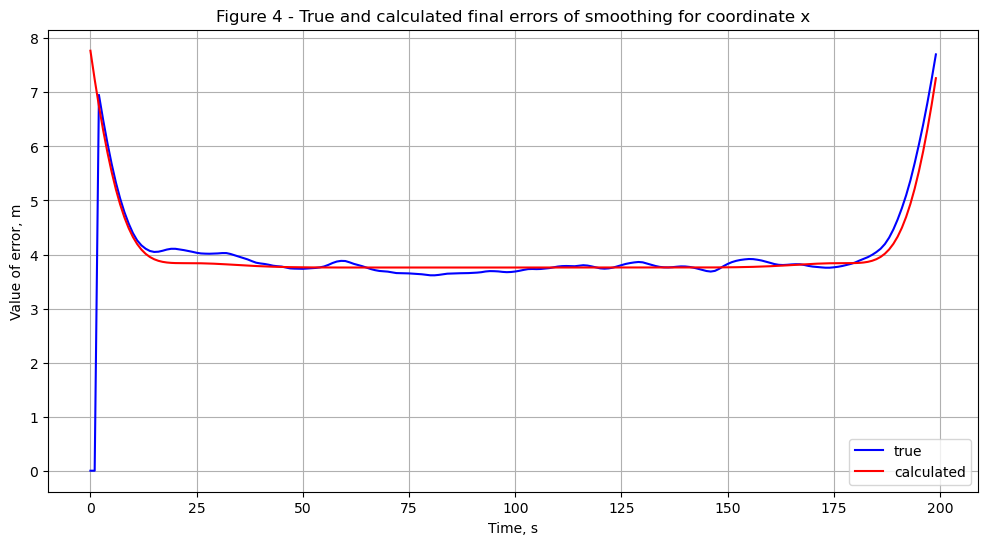

In [12]:
#Plot of the final error and matrix P
plt.figure(figsize=(12, 6))
plt.plot(fin_errsx, color="blue",  label='true')
plt.plot(np.sqrt(P_smoothed[:,0,0]), color="red",  label='calculated')
plt.title('Figure 4 - True and calculated final errors of smoothing for coordinate x')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

In [13]:
#calculate error for smoothed v
M=500
error=np.zeros((M,steps))
error1=np.zeros((M,steps))
fin_errsv=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[10000, 0], [0, 10000]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    P_pred=np.zeros((steps, 2, 2))
    P_pred[0]=np.matrix([[10000, 0], [0, 10000]])
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        P_pred[i] = (fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
    X_smoothed = np.zeros((steps,2,1))
    X_smoothed[steps - 1] = X[steps -1]
    P_smoothed = np.zeros((steps,2,2))
    P_smoothed[steps - 1] = P[steps -1]
    A = np.zeros((steps-1, 2, 2))
    for i in range(steps - 2, -1, -1):
        A[i] = P[i]@fi.T@np.linalg.inv(P_pred[i+1])
        X_smoothed[i] = X[i] + A[i]@(X_smoothed[i+1]-fi@X[i])
        P_smoothed[i] = P[i] + A[i]@(P_smoothed[i+1]-P_pred[i+1])@A[i].T
    for i in range(1,len(x_real)):
        if i>1:
            error[o,i]=(v_real[i]-X_smoothed[i,1,0])**2
for i in range(steps):
    for j in range(M):
        fin_errsv[i]=fin_errsv[i]+((1/(M-1))*error[j,i])
    fin_errsv[i]=sqrt(fin_errsv[i])

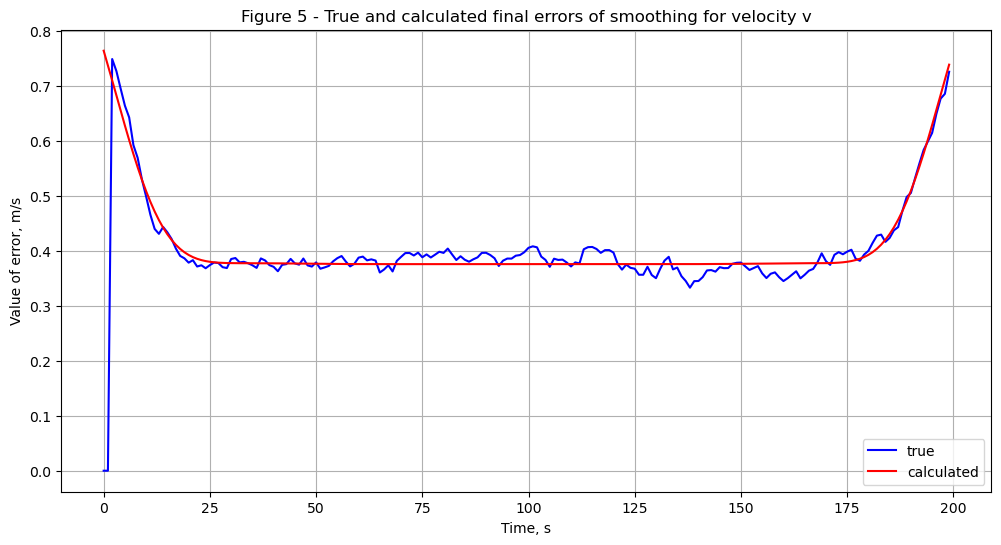

In [14]:
#Plot of the final error and matrix P
plt.figure(figsize=(12, 6))
plt.plot(fin_errsv, color="blue",  label='true')
plt.plot(np.sqrt(P_smoothed[:,1,1]), color="red",  label='calculated')
plt.title('Figure 5 - True and calculated final errors of smoothing for velocity v')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m/s')
plt.legend()
plt.grid()
plt.show()

Let's plot the graphs after filtering and smoothing on one graph to compare the data quality.

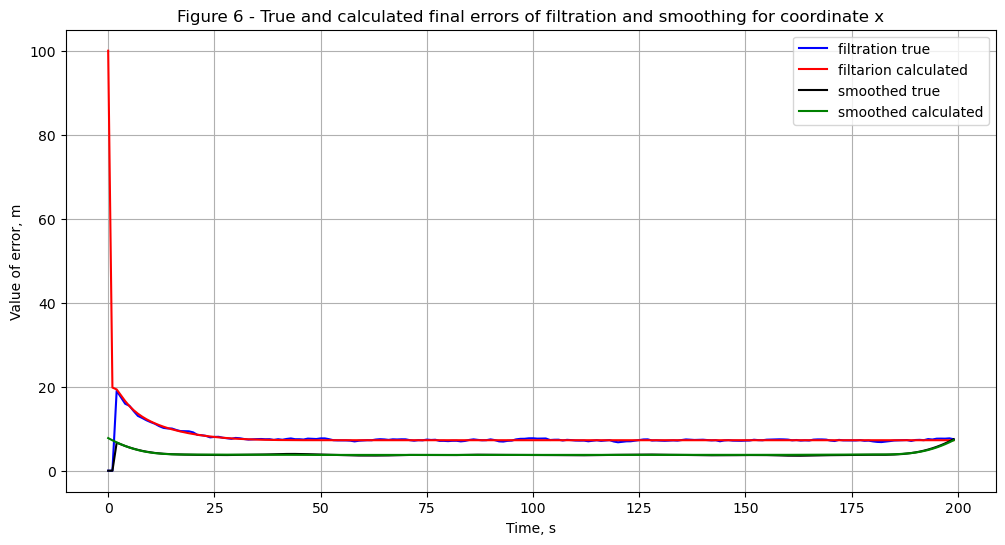

In [15]:
#calculate error for smoothed x
M=500
error=np.zeros((M,steps))
error1=np.zeros((M,steps))
fin_errfx=np.zeros(steps)
fin_errsx=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[10000, 0], [0, 10000]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    P_pred=np.zeros((steps, 2, 2))
    P_pred[0]=np.matrix([[10000, 0], [0, 10000]])
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        P_pred[i] = (fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
        if i>1:
            error1[o,i]=(x_real[i]-X[i,0,0])**2
    X_smoothed = np.zeros((steps,2,1))
    X_smoothed[steps - 1] = X[steps -1]
    P_smoothed = np.zeros((steps,2,2))
    P_smoothed[steps - 1] = P[steps -1]
    A = np.zeros((steps-1, 2, 2))
    for i in range(steps - 2, -1, -1):
        A[i] = P[i]@fi.T@np.linalg.inv(P_pred[i+1])
        X_smoothed[i] = X[i] + A[i]@(X_smoothed[i+1]-fi@X[i])
        P_smoothed[i] = P[i] + A[i]@(P_smoothed[i+1]-P_pred[i+1])@A[i].T
    for i in range(1,len(x_real)):
        if i>1:
            error[o,i]=(x_real[i]-X_smoothed[i,0,0])**2
for i in range(steps):
    for j in range(M):
        fin_errfx[i]=fin_errfx[i]+((1/(M-1))*error1[j,i])
        fin_errsx[i]=fin_errsx[i]+((1/(M-1))*error[j,i])
    fin_errfx[i]=sqrt(fin_errfx[i])
    fin_errsx[i]=sqrt(fin_errsx[i])
#Plot of the final error and matrix P
plt.figure(figsize=(12, 6))
plt.plot(fin_errfx, color="blue",  label='filtration true')
plt.plot(np.sqrt(P[:,0,0]), color="red",  label='filtarion calculated')
plt.plot(fin_errsx, color="black",  label='smoothed true')
plt.plot(np.sqrt(P_smoothed[:,0,0]), color="green",  label='smoothed calculated')
plt.title('Figure 6 - True and calculated final errors of filtration and smoothing for coordinate x')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m')
plt.legend()
plt.grid()
plt.show()

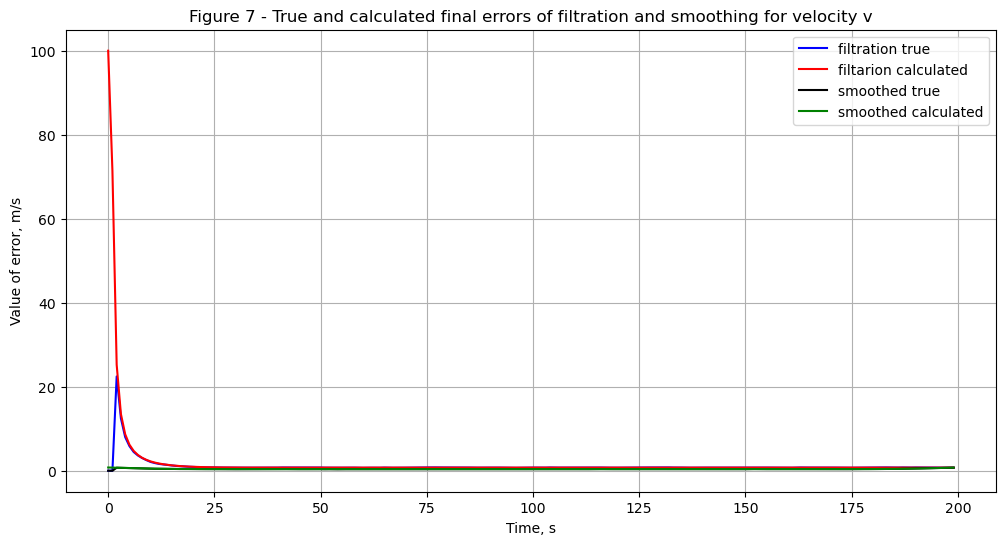

In [16]:
#calculate error for smoothed x
M=500
error=np.zeros((M,steps))
error1=np.zeros((M,steps))
fin_errfv=np.zeros(steps)
fin_errsv=np.zeros(steps)
for o in range(M):
    #generating trajectory
    steps=200
    x_real=np.zeros(steps)
    v_real=np.zeros(steps)
    t=1
    x_real[0]=5
    v_real[0]=1
    for i in range(1,steps):
        a = np.random.normal(0,0.2)
        x_real[i]=x_real[i-1]+v_real[i-1]*t+((a*(t**2))/2)
        v_real[i]=v_real[i-1]+a*t
    #generating_measurements
    z=np.zeros(steps)
    for i in range(0,steps):
        z[i]=x_real[i]+np.random.normal(0,20)
    #transition matrix
    fi=np.matrix([[1,t],[0,1]])
    #input matrix
    g=np.matrix([[(t**2)/2],[t]])
    #observation matrix
    h=np.matrix([1,0])
    #state vector
    X = np.zeros((len(x_real), 2, 1))
    for i in range(len(x_real)):
        X[i] = np.array([[x_real[i]], [v_real[i]]])
    #Initial filtered estimate
    X[0]=np.matrix([[2],[0]])
    #Filtration error covariance matrix
    P=np.zeros((steps, 2, 2))
    P[0]=np.matrix([[10000, 0], [0, 10000]])
    #Covariance matrix
    Q=(g@g.T)*(0.2**2)
    R = np.array(20**2)
    K = np.zeros((steps, 2, 1))
    P_pred=np.zeros((steps, 2, 2))
    P_pred[0]=np.matrix([[10000, 0], [0, 10000]])
    for i in range(1,len(x_real)):
        #step of prediction
        X[i]=fi@X[i-1]
        P[i]=(fi@P[i-1]@fi.T)+Q
        P_pred[i] = (fi@P[i-1]@fi.T)+Q
        #step of filtration
        E=h@P[i]@h.T + R
        K[i]=(P[i]@h.T)/E
        X[i]=X[i]+K[i]*(z[i]-h@X[i])
        P[i]=(np.identity(2)-K[i]@h)@P[i]
        if i>1:
            error1[o,i]=(v_real[i]-X[i,1,0])**2
    X_smoothed = np.zeros((steps,2,1))
    X_smoothed[steps - 1] = X[steps -1]
    P_smoothed = np.zeros((steps,2,2))
    P_smoothed[steps - 1] = P[steps -1]
    A = np.zeros((steps-1, 2, 2))
    for i in range(steps - 2, -1, -1):
        A[i] = P[i]@fi.T@np.linalg.inv(P_pred[i+1])
        X_smoothed[i] = X[i] + A[i]@(X_smoothed[i+1]-fi@X[i])
        P_smoothed[i] = P[i] + A[i]@(P_smoothed[i+1]-P_pred[i+1])@A[i].T
    for i in range(1,len(x_real)):
        if i>1:
            error[o,i]=(v_real[i]-X_smoothed[i,1,0])**2
for i in range(steps):
    for j in range(M):
        fin_errfv[i]=fin_errfv[i]+((1/(M-1))*error1[j,i])
        fin_errsv[i]=fin_errsv[i]+((1/(M-1))*error[j,i])
    fin_errfv[i]=sqrt(fin_errfv[i])
    fin_errsv[i]=sqrt(fin_errsv[i])
#Plot of the final error and matrix P
plt.figure(figsize=(12, 6))
plt.plot(fin_errfv, color="blue",  label='filtration true')
plt.plot(np.sqrt(P[:,1,1]), color="red",  label='filtarion calculated')
plt.plot(fin_errsv, color="black",  label='smoothed true')
plt.plot(np.sqrt(P_smoothed[:,1,1]), color="green",  label='smoothed calculated')
plt.title('Figure 7 - True and calculated final errors of filtration and smoothing for velocity v')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m/s')
plt.legend()
plt.grid()
plt.show()

Let's reduce the range on the y-axis so we can better compare the impact of smoothing the data.

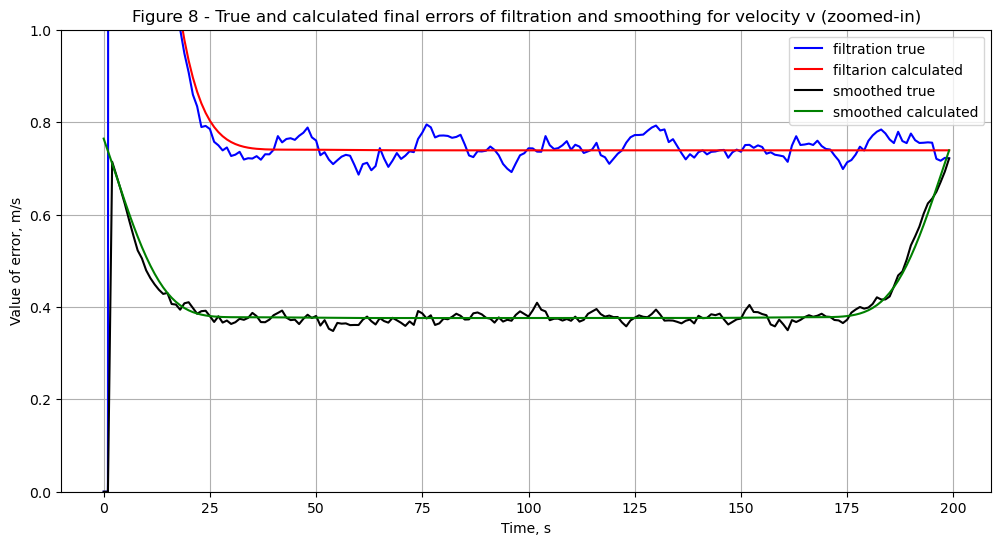

In [17]:
#Plot of the final error and matrix P
plt.figure(figsize=(12, 6))
plt.plot(fin_errfv, color="blue",  label='filtration true')
plt.plot(np.sqrt(P[:,1,1]), color="red",  label='filtarion calculated')
plt.plot(fin_errsv, color="black",  label='smoothed true')
plt.plot(np.sqrt(P_smoothed[:,1,1]), color="green",  label='smoothed calculated')
plt.title('Figure 8 - True and calculated final errors of filtration and smoothing for velocity v (zoomed-in)')
plt.xlabel('Time, s')
plt.ylabel('Value of error, m/s')
plt.ylim(0, 1) 
plt.legend()
plt.grid()
plt.show()

Comparing the error graphs for the filtered and smoothed data, we can see that after smoothing, the error becomes significantly smaller. We can also see that the actual and calculated errors match.

Conclusion: Thus, we have proven that by taking into account current and future measurements, smoothing provides a more accurate estimate. By plotting all two reconstruction types, we found that smoothing produces a sharper trajectory. Also, after plotting the error bars, we found that the error decreases by a factor of 2.

Learning log:

What we learned:

We learned how to improve the Kalman filter. We also learned how to apply smoothing to the data in this case. We also discovered that applying smoothing to filtered data improves quality and significantly reduces error.

What difficulties we faced:

We encountered difficulties understanding the process from a mathematical perspective. We also encountered difficulties in optimizing the filtering and smoothing process so that it would not require a lot of calculation time.